In [3]:
from langchain_openai import ChatOpenAI
import os
from dotenv import load_dotenv

load_dotenv()

llm=ChatOpenAI(
    model=os.getenv("DEEPSEEK_MODEL"),
    api_key=os.getenv("DEEPSEEK_API_KEY"),
    base_url=os.getenv("DEEPSEEK_BASE_URL"),
    temperature=0
)

In [4]:
from langgraph.graph import START, MessagesState, StateGraph,END
from langchain_core.messages import SystemMessage,HumanMessage


def chat_node(state):
    result=llm.invoke(state['messages'])
    return {'messages':result}

def action_node(state):
    system_prompt="""
    将输入的信息翻译成英文返回
    """
    result=llm.invoke([SystemMessage(content=system_prompt),
                       HumanMessage(content=state['messages'][-1].content)])
    return {'messages':result}

builder=StateGraph(MessagesState)

builder.add_node('chat_node',chat_node)
builder.add_node('action_node',action_node)

builder.add_edge(START,'chat_node')
builder.add_edge('chat_node','action_node')
builder.add_edge('action_node',END)

graph=builder.compile()

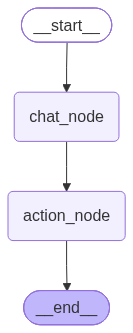

In [5]:
from IPython.display import display,Image

display(Image(graph.get_graph(xray=True).draw_mermaid_png()))

In [6]:
async for chunk in graph.astream({"messages":['你好，介绍一下你自己']},stream_mode="values"):
    chunk['messages'][-1].pretty_print()

================================ Human Message =================================

你好，介绍一下你自己
================================== Ai Message ==================================

你好呀！很高兴认识你！😊

我是**DeepSeek**，由深度求索公司创造的AI助手。让我给你介绍一下我的“特长”：

✨ **我的核心能力**：
- **纯文本对话**：擅长回答各种问题，从日常闲聊到专业知识都可以
- **文件处理**：支持上传图片、PDF、Word、Excel、PPT等文件，能从中提取文字信息帮你分析
- **超长上下文**：拥有1M的上下文窗口，可以一次性处理像《三体》三部曲那么大体量的内容
- **联网搜索**：需要时可以帮你搜索最新信息（需要你手动开启这个功能哦）

🎯 **我的特点**：
- **完全免费**：没错，不收费！你可以放心使用
- **多平台支持**：网页版、App版都有，App还支持语音输入
- **知识更新**：我的知识截止到2025年5月，会尽力提供准确的信息

💡 **我能帮你做什么**：
- 解答疑问、提供建议
- 帮你分析文档、整理信息
- 创作文案、翻译内容
- 编程帮助、学习辅导
- 还有更多你能想到的场景！

有什么我可以帮你的吗？尽管问，我会热情地为你服务！🌟
================================== Ai Message ==================================

Hello there! Nice to meet you! 😊

I'm **DeepSeek**, an AI assistant created by DeepSeek Company. Let me introduce my "specialties":

✨ **My Core Capabilities**:
- **Pure Text Conversation**: Skilled at answering all kinds of questions, from everyday chats to professional kn